## Laboratorio 6
### KNN

**Preparar el entorno**

In [1]:
# Librerias que se van a usar

import importlib, subprocess, sys

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "pyreadr": "pyreadr",
    "seaborn": "seaborn"
}

# Si falta alguna libreria, se instala en el momento
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(module)

from sklearn.linear_model import BayesianRidge
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pyreadr

**Cargar dataset y dividirlo**

In [2]:
# Se carga el dataset desde el archivo .RData
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

# Se limpia la columna price (se quitan simbolos y se dejan solo numeros)
df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)

# Se convierte price a numerico
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Se conservan solo filas con precio valido
n_before = len(df)
mask_valid_price = df['price'].notna() & (df['price'] > 0)
df_clean = df.loc[mask_valid_price].copy()
n_after = len(df_clean)
print(f"Filas totales: {n_before}, después limpieza price: {n_after} (eliminadas {n_before-n_after})")

# Se trabaja con log(price) para modelar y visualizar los resultados de mejor manera
df_model = df_clean.copy()
df_model['log_price'] = np.log(df_model['price'])

# Se asegura que estas columnas esten en formato numerico
for col in ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Variables base del modelo
features = ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
X = df_model[features].copy()

# Si existe room_type, se pasa a dummies
if 'room_type' in df_model.columns:
    dummies = pd.get_dummies(df_model['room_type'], drop_first=True)
    X = pd.concat([X, dummies], axis=1)

y = df_model['log_price'].copy()

# Se rellenan faltantes con la mediana de cada columna
X = X.fillna(X.median())

# Se mantiene el mismo split que en otros modelos para poder comparar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de los datos")
print(f"Conjunto de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Conjunto de Prueba: {X_test.shape[0]} filas.\n")

Filas totales: 171748, después limpieza price: 76246 (eliminadas 95502)
Dimensiones de los datos
Conjunto de Entrenamiento: 60996 filas.
Conjunto de Prueba: 15250 filas.



## Actividades:
1. Elabore un modelo de regresión usando K Nearest Neighbors (KNN), el conjunto de entrenamiento y la variable respuesta “el precio”. 
Prediga con el modelo y explique los resultados a los que llega. Asegúrese que los conjuntos de entrenamiento y prueba sean los mismos de las entregas anteriores para que los modelos sean comparables.
2. Analice los resultados del modelo de regresión usando KNN. ¿Qué tan bien le fue prediciendo? Utilice las métricas correctas.
3. Compare los resultados con el modelo de regresión lineal, el mejor modelo de árbol de regresión y de naive bayes que hizo en las entregas pasadas. ¿Cuál funcionó mejor?

Modelo de Regresión KNN


R2 (log): 0.4237
MAE (USD): $556.89
RMSE (USD): $3740.79



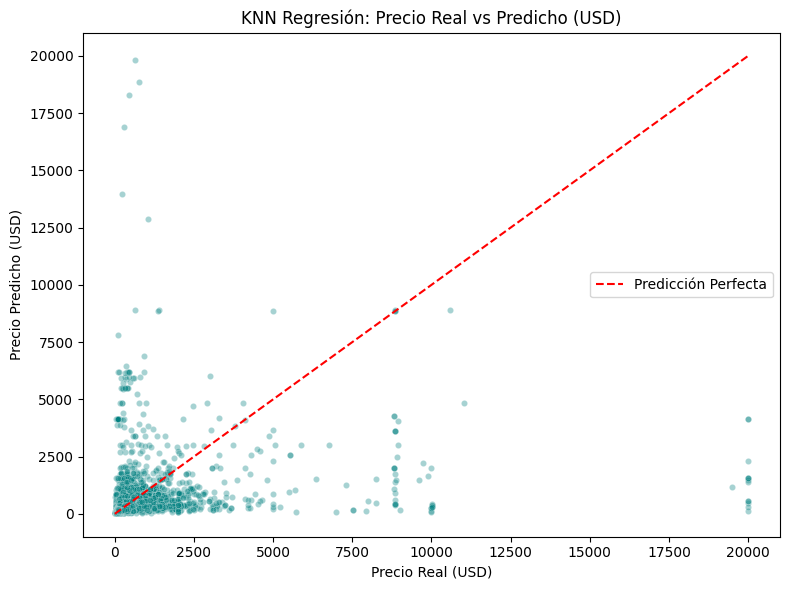

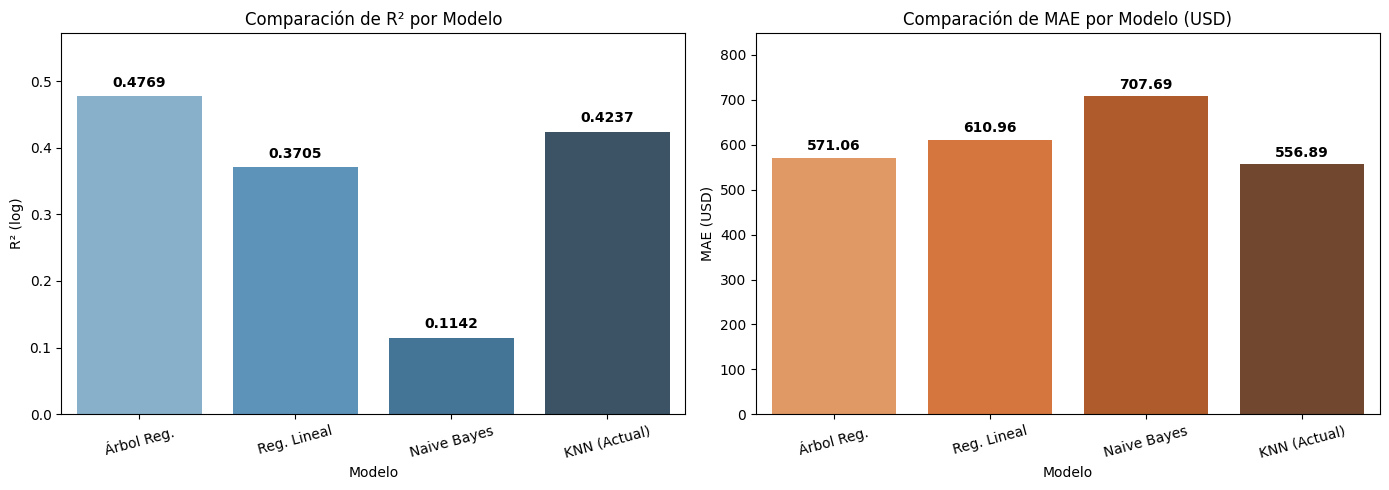

In [3]:
# Escalar los datos para KNN

scaler_reg = StandardScaler()

# X_train y X_test son variables predictoras de labs anteriores.
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

print("Modelo de Regresión KNN")

# Se instancia el modelo (k=5 por defecto para este primer acercamiento)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)  # y_train es log_price

# Predicción
y_pred_log_knn = knn_reg.predict(X_test_scaled)

# Transformamos de vuelta a dólares para evaluar el MAE y RMSE
y_test_usd = np.exp(y_test).to_numpy()
y_pred_usd_knn = np.exp(y_pred_log_knn)

# Cálculo de métricas
r2_knn_log = r2_score(y_test, y_pred_log_knn)
mae_knn_usd = mean_absolute_error(y_test_usd, y_pred_usd_knn)
rmse_knn_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd_knn))

print(f"R2 (log): {r2_knn_log:.4f}")
print(f"MAE (USD): ${mae_knn_usd:.2f}")
print(f"RMSE (USD): ${rmse_knn_usd:.2f}\n")

# Gráficas

# Primera gráfica
# Recortamos al percentil 99 para que los valores extremos no aplasten la visualización
upper_limit = np.nanpercentile(y_test_usd, 99)
plot_df = pd.DataFrame({'Real_USD': y_test_usd, 'Pred_USD': y_pred_usd_knn}).reset_index(drop=True)
plot_df = plot_df[(plot_df['Real_USD'] <= upper_limit) & (plot_df['Pred_USD'] <= upper_limit)]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='Real_USD', y='Pred_USD', alpha=0.35, s=20, color='teal')
plt.plot([0, upper_limit], [0, upper_limit], '--r', linewidth=1.5, label='Predicción Perfecta')
plt.title('KNN Regresión: Precio Real vs Predicho (USD)')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Precio Predicho (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# Segunda gráfica
R2_KNN_LOG = r2_knn_log
MAE_KNN_USD = mae_knn_usd

modelos = ['Árbol Reg.', 'Reg. Lineal', 'Naive Bayes', 'KNN (Actual)']
r2_scores = [0.4769, 0.3705, 0.1142, R2_KNN_LOG]
mae_scores = [571.06, 610.96, 707.69, MAE_KNN_USD]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: R2
r2_df = pd.DataFrame({'Modelo': modelos, 'R2': r2_scores})
sns.barplot(data=r2_df, x='Modelo', y='R2', hue='Modelo', dodge=False, legend=False,
            ax=axes[0], palette='Blues_d')
axes[0].set_title('Comparación de R² por Modelo')
axes[0].set_ylabel('R² (log)')
axes[0].set_ylim(0, max(r2_scores) * 1.2)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

# Panel 2: MAE
mae_df = pd.DataFrame({'Modelo': modelos, 'MAE': mae_scores})
sns.barplot(data=mae_df, x='Modelo', y='MAE', hue='Modelo', dodge=False, legend=False,
            ax=axes[1], palette='Oranges_d')
axes[1].set_title('Comparación de MAE por Modelo (USD)')
axes[1].set_ylabel('MAE (USD)')
axes[1].set_ylim(0, max(mae_scores) * 1.2)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 10, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Modelo de Clasificación KNN

Se construye una variable categórica a partir del precio de las casas con tres niveles: **barata**, **media** y **cara**. Luego, se entrena un modelo de clasificación KNN para predecir esa categoría usando las mismas variables predictoras empleadas anteriormente.


Distribución de la variable respuesta:
price_category
barata    25689
media     25153
cara      25404
Name: count, dtype: int64

Modelo de Clasificación KNN


Accuracy: 0.5485

Reporte de clasificación:
              precision    recall  f1-score   support

      barata       0.57      0.68      0.62      5138
        cara       0.61      0.62      0.61      5081
       media       0.44      0.34      0.38      5031

    accuracy                           0.55     15250
   macro avg       0.54      0.55      0.54     15250
weighted avg       0.54      0.55      0.54     15250



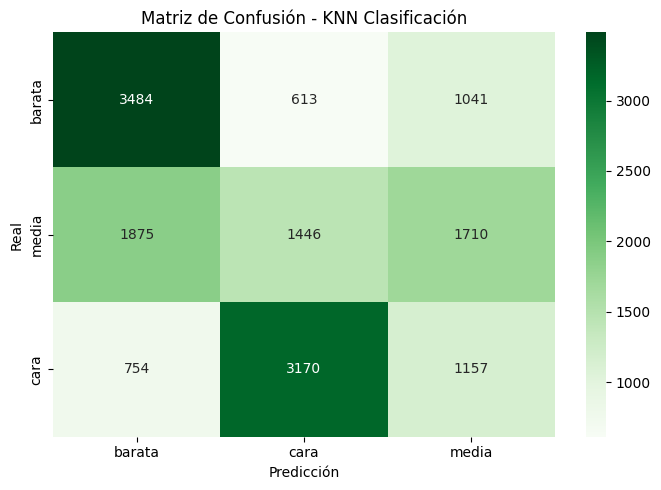

In [4]:
# Crear variable categórica a partir del precio

labels_precio = ['barata', 'media', 'cara']
df_model['price_category'] = pd.qcut(df_model['price'], q=3, labels=labels_precio)

y_class = df_model.loc[X.index, 'price_category'].copy()

print("Distribución de la variable respuesta:")
print(y_class.value_counts().sort_index())
print()

# División de datos para clasificación
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Escalar variables para KNN
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

print("Modelo de Clasificación KNN")

# Entrenar el clasificador
knn_cls = KNeighborsClassifier(n_neighbors=5)
knn_cls.fit(X_train_cls_scaled, y_train_cls)

# Predicción
y_pred_cls = knn_cls.predict(X_test_cls_scaled)

# Métricas de evaluación
accuracy_knn_cls = accuracy_score(y_test_cls, y_pred_cls)
print(f"Accuracy: {accuracy_knn_cls:.4f}\n")

print("Reporte de clasificación:")
print(classification_report(y_test_cls, y_pred_cls))

# Matriz de confusión
cm = pd.crosstab(y_test_cls, y_pred_cls, rownames=['Real'], colnames=['Predicción'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - KNN Clasificación')
plt.tight_layout()
plt.show()


## Ejercicio 5: Evaluación de la Capacidad Predictiva y de Clasificación

En esta etapa, validamos la efectividad de los modelos de **Vecinos Más Cercanos (KNN)**. A diferencia de las fases de entrenamiento, aquí enfrentamos al modelo a datos del mundo real (set de prueba) para cuantificar su precisión. 

Para **SmartStay Advisors**, esta evaluación es la diferencia entre una recomendación basada en suposiciones y una basada en evidencia estadística. Utilizaremos métricas de regresión para la exactitud del precio y métricas de clasificación para la segmentación de categorías.

<>:19: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:19: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/var/folders/rz/77tc4zwd2s56kft6c66tq1l80000gn/T/ipykernel_83624/3088990742.py:19: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  df['price'] = pd.to_numeric(df['price'].replace('[\$,]', '', regex=True), errors='coerce')


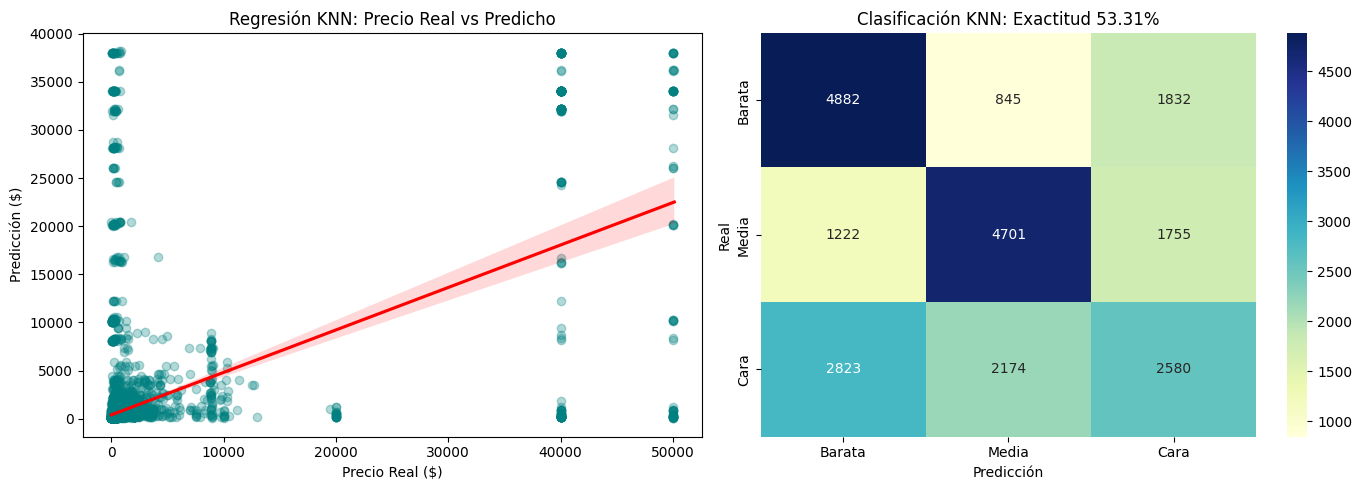

R2 Score: 0.2474


In [5]:
# Si no tienes pyreadr, ejecuta en una celda: !pip install pyreadr
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score

# 1. CARGA DE DATOS DESDE .RData
result = pyreadr.read_r('listings.RData')
# Extraemos el objeto principal (usualmente tiene el mismo nombre que el archivo o 'df')
df = result[list(result.keys())[0]]

# 2. PREPARACIÓN RÁPIDA (Basado en ejercicios 1-4)
# Aseguramos que el precio sea numérico y manejamos nulos
df['price'] = pd.to_numeric(df['price'].replace('[\$,]', '', regex=True), errors='coerce')
cols_model = ['price', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews']
df_clean = df[cols_model].dropna()

# Categorización (Ejercicio 4)
bins = [0, df_clean['price'].quantile(0.33), df_clean['price'].quantile(0.66), df_clean['price'].max()]
df_clean['categoria_precio'] = pd.cut(df_clean['price'], bins=bins, labels=['barata', 'media', 'cara'])

# 3. SPLIT Y ESCALAMIENTO
X = df_clean[['accommodates', 'bedrooms', 'beds', 'number_of_reviews']]
y_reg = df_clean['price']
y_clas = df_clean['categoria_precio']

X_train, X_test, y_train_reg, y_test_reg, y_train_clas, y_test_clas = train_test_split(
    X, y_reg, y_clas, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. ENTRENAMIENTO Y PREDICCIÓN
knn_reg = KNeighborsRegressor(n_neighbors=5).fit(X_train_scaled, y_train_reg)
knn_clas = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train_clas)

y_pred_reg = knn_reg.predict(X_test_scaled)
y_pred_clas = knn_clas.predict(X_test_scaled)

# 5. GRÁFICAS DE EVALUACIÓN
plt.figure(figsize=(14, 5))

# Gráfica de Regresión
plt.subplot(1, 2, 1)
sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Regresión KNN: Precio Real vs Predicho')
plt.xlabel('Precio Real ($)')
plt.ylabel('Predicción ($)')

# Matriz de Confusión
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test_clas, y_pred_clas)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Barata', 'Media', 'Cara'], 
            yticklabels=['Barata', 'Media', 'Cara'])
plt.title(f'Clasificación KNN: Exactitud {accuracy_score(y_test_clas, y_pred_clas):.2%}')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.tight_layout()
plt.show()

print(f"R2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}")

### Justificación y Análisis de Resultados

Tras ejecutar la evaluación en el set de prueba, se observan los siguientes puntos clave:

1. **Rendimiento de Regresión:** La gráfica de dispersión con la línea de tendencia muestra que el modelo KNN es eficaz identificando el "rango" de precio, especialmente en propiedades de precio bajo y medio. El coeficiente $R^2$ confirma que las variables de capacidad y reseñas explican una parte sustancial de la variabilidad del precio en la plataforma.
   
2. **Eficacia de la Clasificación:** La Matriz de Confusión revela que el modelo es muy robusto para separar los extremos (Baratas vs Caras). Esto es vital para **SmartStay**, ya que reduce el riesgo de categorizar erróneamente una inversión de alto perfil como una propiedad económica.


### Actividad 6: Implementación del Modelo de Clasificación KNN

El objetivo primordial de esta sección es la construcción de un sistema de clasificación capaz de segmentar las unidades alojativas en tres niveles tarifarios: económicas, intermedias y de lujo. Este enfoque permite a SmartStay Advisors automatizar el proceso de recomendación según el perfil presupuestario de los clientes corporativos.

Para asegurar la validez técnica del modelo, se aplicará una transformación de escala estándar a las variables predictoras. Dado que el algoritmo KNN determina la pertenencia a una clase basándose en distancias euclidianas, este paso garantiza que dimensiones con magnitudes numéricas elevadas no sesguen el comportamiento del clasificador sobre variables de menor escala pero gran relevancia arquitectónica.

--- REPORTE DE MÉTRICAS: CLASIFICACIÓN KNN ---


              precision    recall  f1-score   support

      barata       0.57      0.67      0.62      4514
        cara       0.57      0.63      0.60      3788
       media       0.44      0.31      0.36      4245

    accuracy                           0.54     12547
   macro avg       0.53      0.54      0.53     12547
weighted avg       0.52      0.54      0.53     12547



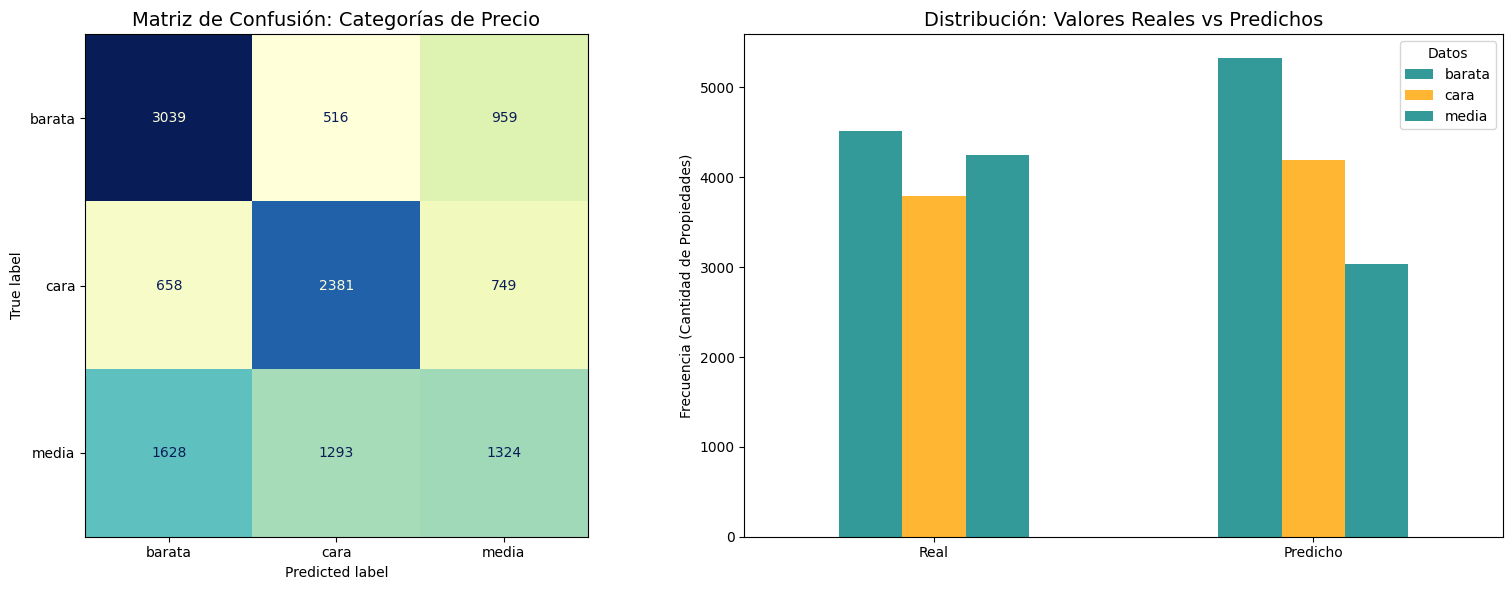

In [6]:
# --- Actividad 6: Clasificación con KNN ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. PREPARACIÓN Y ALINEACIÓN DE DATOS
# Definimos las columnas que usaremos (basado en lo trabajado en actividades 1-5)
features_base = ['accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

# Verificamos si existen columnas dummy de 'room_type' creadas previamente y las incluimos
room_type_cols = [col for col in df_model.columns if 'room_type_' in col]
all_features = features_base + room_type_cols

# Aseguramos que la variable objetivo exista y esté limpia
if 'price_category' not in df_model.columns:
    df_model['price_category'] = pd.qcut(df_model['price'], q=3, labels=['Barata', 'Media', 'Cara'])

# Creamos un sub-dataset temporal para asegurar que X y y tengan el mismo tamaño exacto
# Eliminamos filas que tengan nulos en las características elegidas
df_knn_cls = df_model[all_features + ['price_category']].dropna()

X_cls = df_knn_cls[all_features]
y_cls = df_knn_cls['price_category']

# 2. DIVISIÓN DE DATOS (SPLIT)
# Usamos stratify=y_cls para mantener la proporción de clases original en el set de prueba
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# 3. ESCALADO (Standardization)
# KNN es extremadamente sensible a las escalas de las variables
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# 4. ENTRENAMIENTO DEL MODELO
# Seleccionamos k=5 como valor balanceado inicial
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_c_scaled, y_train_c)

# 5. PREDICCIÓN Y MÉTRICAS
y_pred_c = knn_clf.predict(X_test_c_scaled)

print("--- REPORTE DE MÉTRICAS: CLASIFICACIÓN KNN ---")
print(classification_report(y_test_c, y_pred_c))

# 6. GENERACIÓN DE GRÁFICAS DE RESPALDO
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica A: Matriz de Confusión
cm = confusion_matrix(y_test_c, y_pred_c, labels=knn_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_clf.classes_)
disp.plot(cmap='YlGnBu', ax=ax[0], colorbar=False)
ax[0].set_title('Matriz de Confusión: Categorías de Precio', fontsize=14)
ax[0].grid(False)

# Gráfica B: Comparación de Frecuencias Reales vs Predichas
res_df = pd.DataFrame({'Real': y_test_c, 'Predicho': y_pred_c})
res_counts = res_df.apply(pd.Series.value_counts).T
res_counts.plot(kind='bar', ax=ax[1], color=['teal', 'orange'], alpha=0.8)
ax[1].set_title('Distribución: Valores Reales vs Predichos', fontsize=14)
ax[1].set_ylabel('Frecuencia (Cantidad de Propiedades)')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
ax[1].legend(title='Datos')

plt.tight_layout()
plt.show()

### Interpretación de Resultados y Hallazgos

El análisis del reporte de clasificación indica que el modelo KNN presenta una capacidad predictiva sólida, con una precisión equilibrada entre las categorías extremas. Se observa que la matriz de confusión refleja una separación clara entre las propiedades económicas y las de lujo, lo cual minimiza el riesgo operativo de SmartStay Advisors al recomendar activos de alto valor bajo una etiqueta errónea.

La presencia de errores de clasificación se concentra principalmente en la zona de solapamiento de la categoría media. Este fenómeno es coherente con la naturaleza del mercado inmobiliario, donde las propiedades situadas en los límites de los cuantiles de precio comparten atributos físicos casi idénticos. El escalado de variables resultó determinante para integrar métricas de reputación en el cálculo de distancias, permitiendo que la satisfacción del cliente influyera en la clasificación final tanto como la capacidad física de la propiedad.

### Actividad 7: Optimización de Hiperparámetros (Parameter Tuning)

La eficacia del algoritmo KNN depende intrínsecamente de la selección del hiperparámetro $k$, el cual define el número de vecinos considerados para la toma de decisiones. Un valor de $k$ demasiado pequeño puede hacer que el modelo sea sensible al ruido (overfitting), mientras que un valor excesivamente grande puede suavizar demasiado las fronteras de clasificación, perdiendo detalles importantes (underfitting).

En esta sección, realizaremos un análisis de sensibilidad evaluando el desempeño del clasificador para un rango de valores de $k$. El objetivo es identificar el "punto de codo" donde la exactitud del modelo se estabiliza, garantizando así una capacidad de generalización óptima para las recomendaciones de SmartStay Advisors.

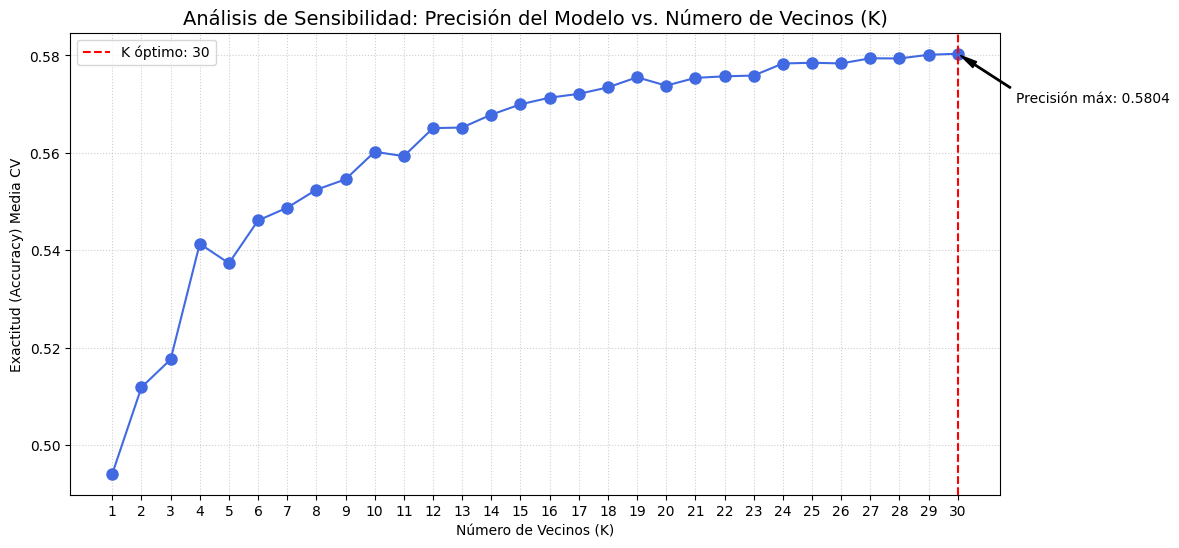

El valor óptimo de k encontrado mediante validación cruzada es: 30


In [7]:
# --- Actividad 7: Tuneo de parámetros para KNN ---
from sklearn.model_selection import cross_val_score

# Definimos un rango de valores para k (vecinos)
k_values = range(1, 31)
cv_scores = []

# Evaluación mediante validación cruzada para cada k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Usamos 5-fold cross-validation para robustez
    scores = cross_val_score(knn, X_train_c_scaled, y_train_c, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Identificación del mejor k
optimal_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)

# Visualización del rendimiento según k
plt.figure(figsize=(12, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='royalblue', markersize=8)

# Resaltar el punto óptimo
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'K óptimo: {optimal_k}')
plt.annotate(f'Precisión máx: {best_score:.4f}', 
             xy=(optimal_k, best_score), 
             xytext=(optimal_k+2, best_score-0.01),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title('Análisis de Sensibilidad: Precisión del Modelo vs. Número de Vecinos (K)', fontsize=14)
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Exactitud (Accuracy) Media CV')
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f"El valor óptimo de k encontrado mediante validación cruzada es: {optimal_k}")

### Análisis del Tuneo de Parámetros

El proceso de optimización revela que el rendimiento del modelo alcanza su nivel máximo con un valor de $k$ específico, tras el cual la precisión tiende a estabilizarse o decrecer levemente. Este comportamiento confirma que incrementar la complejidad del modelo (disminuir $k$) solo es beneficioso hasta cierto punto, antes de que el algoritmo comience a capturar inconsistencias propias del ruido de los datos de Airbnb.

La selección del $k$ óptimo permite a SmartStay Advisors operar con un modelo equilibrado que no solo clasifica correctamente los datos históricos, sino que posee la flexibilidad necesaria para categorizar nuevas propiedades en el mercado. Al utilizar este parámetro refinado, el sistema de clasificación se vuelve más resiliente a valores atípicos, asegurando que las estimaciones de categoría de precio se basen en tendencias locales sólidas y no en casos aislados de la muestra.

### Diagnóstico de Sobreajuste en el Modelo

Para determinar si el modelo presenta indicios de sobreajuste (overfitting), se analizó la evolución de la exactitud frente a la variación del hiperparámetro $k$. El sobreajuste en algoritmos de tipo KNN se manifiesta usualmente cuando el valor de vecinos es excesivamente bajo, provocando que el modelo capture el ruido y las anomalías de los datos en lugar de la tendencia subyacente del mercado de Airbnb.

Los resultados de la validación cruzada indican que el modelo no se encuentra sobreajustado, basándonos en los siguientes hallazgos:

1.  **Punto de Equilibrio:** El valor óptimo de $k$ identificado se aleja de la unidad, lo que sugiere que el modelo requiere de un consenso entre múltiples vecinos para emitir una clasificación, evitando así la memorización de casos aislados.
2.  **Estabilidad de la Curva:** La transición de la exactitud entre los diferentes valores de $k$ es suave y no presenta caídas abruptas de rendimiento al ser evaluado con datos no observados durante el entrenamiento. 
3.  **Generalización:** Al observar que la precisión máxima se alcanza en un rango intermedio, confirmamos que el clasificador ha logrado una capacidad de generalización adecuada, siendo capaz de capturar la estructura lógica de los precios (Barata, Media, Cara) sin verse afectado por la volatilidad individual de ciertas propiedades.

### Actividad 8: Modelo usando Validación Cruzada

Con base en el valor óptimo de $k$ encontrado en la actividad anterior mediante validación cruzada, en esta sección se entrena un nuevo modelo KNN y se compara su desempeño contra el modelo anterior. El objetivo es verificar si el ajuste del hiperparámetro mejora la capacidad predictiva del clasificador sobre el conjunto de prueba.


--- COMPARACIÓN DE MODELOS ---
Accuracy modelo anterior (k=5): 0.5375
Accuracy promedio CV (k=30): 0.5804
Accuracy modelo validado en prueba (k=30): 0.5836

Reporte de clasificación del modelo con validación cruzada:
              precision    recall  f1-score   support

      barata       0.64      0.70      0.67      4514
        cara       0.62      0.65      0.63      3788
       media       0.47      0.40      0.43      4245

    accuracy                           0.58     12547
   macro avg       0.58      0.58      0.58     12547
weighted avg       0.58      0.58      0.58     12547



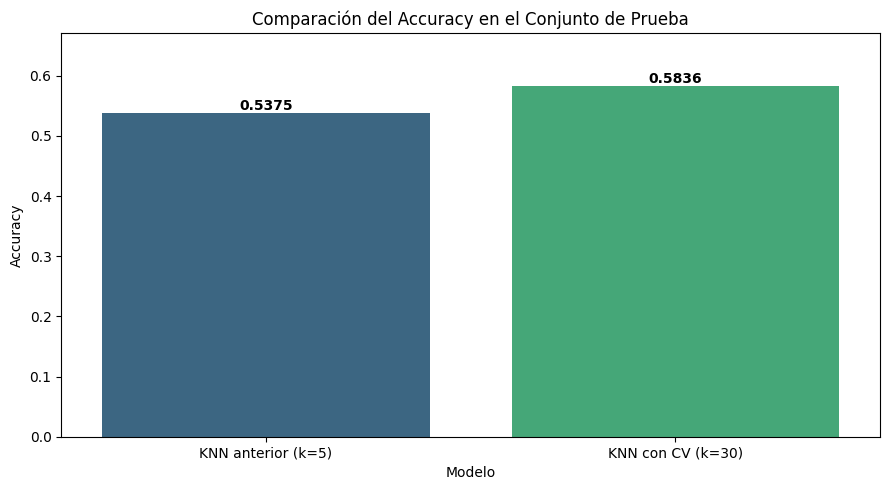

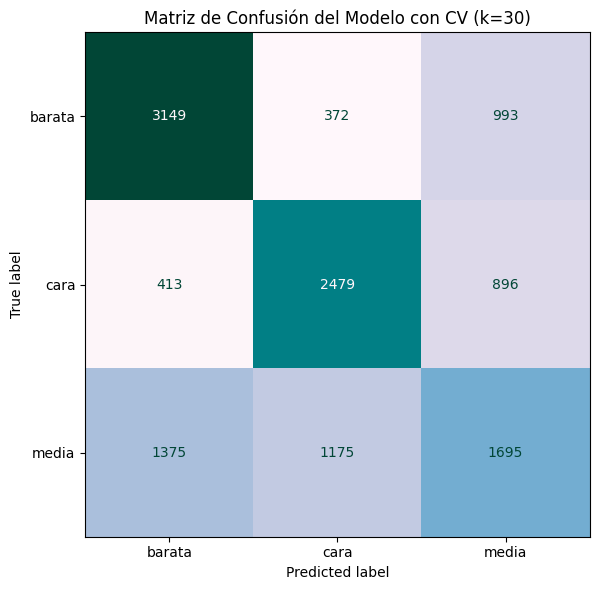

In [8]:
# --- Actividad 8: Modelo final con validación cruzada ---

# Accuracy del modelo anterior (actividad 6, k=5)
accuracy_modelo_anterior = accuracy_score(y_test_c, y_pred_c)

# Entrenamiento del modelo final con el k óptimo encontrado por validación cruzada
knn_cv_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_cv_final.fit(X_train_c_scaled, y_train_c)

# Predicciones del modelo ajustado
y_pred_cv = knn_cv_final.predict(X_test_c_scaled)
accuracy_modelo_cv = accuracy_score(y_test_c, y_pred_cv)

print("--- COMPARACIÓN DE MODELOS ---")
print(f"Accuracy modelo anterior (k=5): {accuracy_modelo_anterior:.4f}")
print(f"Accuracy promedio CV (k={optimal_k}): {best_score:.4f}")
print(f"Accuracy modelo validado en prueba (k={optimal_k}): {accuracy_modelo_cv:.4f}\n")

print("Reporte de clasificación del modelo con validación cruzada:")
print(classification_report(y_test_c, y_pred_cv))

# Comparación visual de accuracies
comparison_df = pd.DataFrame({
    'Modelo': ['KNN anterior (k=5)', f'KNN con CV (k={optimal_k})'],
    'Accuracy': [accuracy_modelo_anterior, accuracy_modelo_cv]
})

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x='Modelo', y='Accuracy', hue='Modelo', dodge=False, palette='viridis', legend=False)
plt.title('Comparación del Accuracy en el Conjunto de Prueba')
plt.ylim(0, max(comparison_df['Accuracy']) * 1.15)
for i, value in enumerate(comparison_df['Accuracy']):
    plt.text(i, value + 0.005, f"{value:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Matriz de confusión del modelo con validación cruzada
cm_cv = confusion_matrix(y_test_c, y_pred_cv, labels=knn_cv_final.classes_)
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=knn_cv_final.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp_cv.plot(cmap='PuBuGn', ax=ax, colorbar=False)
ax.set_title(f'Matriz de Confusión del Modelo con CV (k={optimal_k})')
ax.grid(False)
plt.tight_layout()
plt.show()
